#### [ Cat & Dog Classification ]

- 커스텀데이터셋 생성 => ImageFolder : 사용자 정의 이미지 데이터셋 생성 
- 훈련 & 검증셋 분리 => random_split : 훈련/검증 데이터 랜덤 비율 분리
- 모델 & 가중치 저장 => save()/state_dict(), load()/load_state_dict()

[1] 모듈 로딩 및 데이터 준비 <hr>

In [12]:
## 모듈 로딩 
import torch                                            ## 텐서 및 기본 함수들 모듈
import torch.nn as nn                                   ## 인공신경망 관련 모듈
import torch.nn.functional as F                         ## 인공신경망 관련 함수들 모듈
import torch.optim as optim                             ## 인공신경망 관련 최적화 모듈
from torch.optim.lr_scheduler import ReduceLROnPlateau  ## 학습률 조정 

from torchinfo import summary                           ## 모델 정보 및 구조 확인 모듈
from torchmetrics.classification import *               ## 모델 성능 지표 관련 모듈

from torchvision.datasets import ImageFolder            ## 이미지용 데이터셋 생성 모듈
from torch.utils.data import DataLoader                 ## 데이터 셋 관련 모듈
from torch.utils.data import Subset, random_split       
from torchvision.transforms import transforms           ## 이미지 전처리 및 증강 모듈

import matplotlib.pyplot as plt                         ## 이미지 시각화 

In [13]:
## 데이터 준비
IMG_ROOT ='../_image/cat_dog/'

[2] 데이터 로딩 및 데이터셋 준비 <hr>

- [2-1] 이미지 데이터 전처리용 인스턴스 생성

In [14]:
## [2-1] 이미지 전처리 및 변형 
## - resize   => 이미지 크기 통일             ==> transforms.Resize((shape))
## - tensor화 => Pytorch 모델 입력 타입 변환  ==> transforms.ToTensor() 
##                                             텐서화 + (C, H, W) 변경 + 정규화(0.~1.)
preprocessing = transforms.Compose(
    [
        transforms.Resize((100,100)),           ## 크기 조정
        transforms.RandomHorizontalFlip(0.5),   ## 50% 랜덤 수평/좌우 뒤집기
        transforms.ToTensor()                   ## (H,W,C) => (C, H, W) + 정규화 + 텐서화
    ]
)


- [2-2] 이미지 데이터 로딩 

In [15]:
## - 이미지 데이터 로딩 
imgDS = ImageFolder(root=IMG_ROOT, 
                    transform=preprocessing)

## - 클래스 변환 데이터 
IDX_TO_CLASS = {v:k for k, v in imgDS.class_to_idx.items()}
print(f'IDX_TO_CLASS => {IDX_TO_CLASS}')

IDX_TO_CLASS => {0: 'cat', 1: 'dog'}


In [16]:
## - 데이터 확인
print(f'imgDataset 개수 : {len(imgDS.targets)}개')
print(f'imgDataset 분류 : {imgDS.class_to_idx}')
print(f'- cat      개수 : {imgDS.targets.count(0)}개, {(imgDS.targets.count(0)/len(imgDS.targets))*100}')
print(f'- dog      개수 : {imgDS.targets.count(1)}개, {(imgDS.targets.count(1)/len(imgDS.targets))*100}')

imgDataset 개수 : 138개
imgDataset 분류 : {'cat': 0, 'dog': 1}
- cat      개수 : 60개, 43.47826086956522
- dog      개수 : 78개, 56.52173913043478


- [2-3] 훈련용/검증용/테스트용 데이터셋 분리 => 훈련용:검증용:테스트용 = 80:10:10

In [17]:
## 방법 1) 일반적인 분리
## -------(1) 훈련용:검증용:테스트용 데이터 개수 설정
dataset_size = len(imgDS)
train_size = int(dataset_size * 0.8)
valid_size = int(dataset_size * 0.1)
test_size  = dataset_size - train_size - valid_size

## -------(2) 훈련용/검증용/테스트용
trainDS, validDS, testDS= random_split(imgDS, 
                                       [train_size, valid_size, test_size], 
                                       generator=torch.Generator().manual_seed(42))


In [18]:
## -------(3) 분리 데이터셋의 클래스 비율 체크
for kind, indices in zip(['Train', 'Valid', 'Test'], [trainDS.indices, validDS.indices, testDS.indices]):
    targets = [ imgDS.targets[ idx ] for idx in indices ]
    print(f'\n[{kind} 전체 데이터셋 개수 : {len(targets)}개')
    print(f'        - cat      개수 : {targets.count(0):02}개 {(targets.count(0)/len(targets))*100:.2f}')
    print(f'        - dog      개수 : {targets.count(1):02}개 {(targets.count(1)/len(targets))*100:.2f}')


[Train 전체 데이터셋 개수 : 110개
        - cat      개수 : 45개 40.91
        - dog      개수 : 65개 59.09

[Valid 전체 데이터셋 개수 : 13개
        - cat      개수 : 05개 38.46
        - dog      개수 : 08개 61.54

[Test 전체 데이터셋 개수 : 15개
        - cat      개수 : 10개 66.67
        - dog      개수 : 05개 33.33


In [19]:
## 방법 2) 층화 샘플링(stratified sampling)

## -------(1) 비율 기준 설정
## 모듈 로딩
from sklearn.model_selection import train_test_split  

## 전체 데이터 수 체크
print('[전체 데이터 수 체크 ]', len(imgDS.imgs), len(imgDS.targets))

## 비율 기준 설정
targets = imgDS.targets

## -------(2) 훈련용:검증용:테스트용 데이터 인덱스 추출
## 1단계: 학습용과 검증용 데이터셋 분리
train_indices, valid_indices = train_test_split(range(len(imgDS.targets)),
                                                test_size=0.2, random_state=42, 
                                                stratify=targets)

## 2단계: 검증용 데이터셋을 테스트용 데이터셋 분리
targets = [ targets[index] for index in valid_indices ]
valid_indices, test_indices= train_test_split( valid_indices,
                                               test_size=0.5, random_state=42, 
                                               stratify=targets)

## -------(3) 훈련용:검증용:테스트용 데이터셋 생성
trainDS = Subset(imgDS, train_indices)
validDS = Subset(imgDS, valid_indices)
testDS = Subset(imgDS, test_indices)

## -------(4) 분리 데이터셋의 클래스 비율 체크
for kind, indices in zip(['Train','Valid','Test'], [trainDS.indices, validDS.indices, testDS.indices]):
    targets = [ imgDS.targets[ idx ] for idx in indices ]
    print(f'\n[{kind} 전체 데이터셋 개수 : {len(targets)}개')
    print(f'        - cat      개수 : {targets.count(0):02}개 {(targets.count(0)/len(targets))*100:.2f}')
    print(f'        - dog      개수 : {targets.count(1):02}개 {(targets.count(1)/len(targets))*100:.2f}')

[전체 데이터 수 체크 ] 138 138

[Train 전체 데이터셋 개수 : 110개
        - cat      개수 : 48개 43.64
        - dog      개수 : 62개 56.36

[Valid 전체 데이터셋 개수 : 14개
        - cat      개수 : 06개 42.86
        - dog      개수 : 08개 57.14

[Test 전체 데이터셋 개수 : 14개
        - cat      개수 : 06개 42.86
        - dog      개수 : 08개 57.14


[3] 데이터 로더 준비<hr>

- [3-1] 데이터 로더 생성

In [20]:
## - 훈련용/검증용/테스트용 데이터 로더 생성
trainDL = DataLoader(trainDS, 
                     shuffle=True, 
                     generator=torch.Generator().manual_seed(42))
validDL = DataLoader(validDS, shuffle=False)
testDL  = DataLoader(testDS,  shuffle=False)


In [21]:
import torch

# 전체 PyTorch 난수 생성기 시드 설정, 전역적으로 모든 랜덤 생성기의 시드를 설정 즉, PyTorch의 모든 연산에 영향
torch.manual_seed(42)
print(torch.rand(2, 2))  # 동일한 난수 생성

# 별도의 난수 생성기 생성 즉, 특정 generator의 시드 설정, 특정 Generator 객체에만 영향
# 여러 개의 난수 생성기를 독립적으로 사용할 때 유용
# 다른 생성기나 PyTorch 전역 난수 생성기에는 영향을 주지 않음
# 예) 여러 개의 난수 생성기를 사용하여 서로 다른 연산에 대한 난수를 각각 제어하고 싶을 때 사용

generator = torch.Generator().manual_seed(42)
print(torch.rand(2, 2, generator=generator))  # 동일한 난수 생성


tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])


torch.Size([1, 3, 100, 100]) tensor([0]) cat


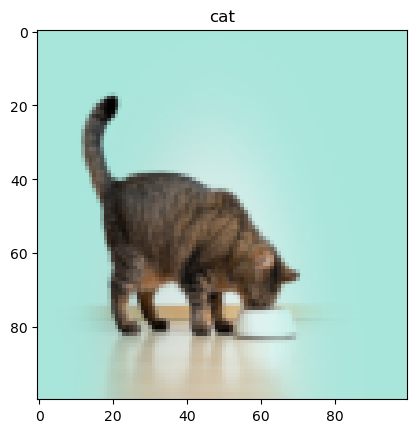

In [22]:
## 체크
img, target = next(iter(trainDL))
print(img.shape, target, IDX_TO_CLASS[target.item()])
plt.imshow(img[0].permute(1,2,0))
plt.title(IDX_TO_CLASS[target.item()])
plt.show()


In [48]:

class CD_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        ## 특징맵 추출 부분
        self.conv1 = nn.Conv2d(3, 16, kernel_size=4, padding=1)  # (B, 3, 50, 50) -> (B, 16, 50, 50)
        self.pool1 = nn.MaxPool2d(2, 2)                          # (B, 16, 50, 50) -> (B, 16, 25, 25)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, padding=1) # (B, 16, 25, 25) -> (B, 32, 25, 25)
        self.pool2 = nn.MaxPool2d(2, 2)                          # (B, 32, 25, 25) -> (B, 32, 12, 12)
        
        self.flatten = nn.Flatten()  # (B, 32, 12, 12) -> (B, 32 * 12 * 12)

        ## 전결합 학습 부분
        self.fc1 = nn.Linear(18432,512)  # 4608 -> 512
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.25)
        self.fc4 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)  # 이진 분류

        

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.relu(self.fc4(x))
        x = self.out(x)  

        return x  # BCEWithLogitsLoss() 사용 시, Sigmoid 적용 안 함.

In [49]:
test = CD_CNN()
import sys

sys.path.append('../_utils/')
from DL_Module import TT_classifier
testCF = TT_classifier(test, trainDS, validDS, 
                       batch_size=10,
                       LOSS_FN=nn.BCEWithLogitsLoss())


EPOCHS : 100
ITERATION : 11
LOSS_FN : BCEWithLogitsLoss()


In [50]:
HIST = testCF.cycling()

torch.Size([14, 3, 100, 100])
torch.Size([14])

EPOCH[0/100]----------------
- TRAIN_LOSS 0.69114  ACC 0.44545
- VALID_LOSS 0.68438  ACC 0.42857
5.00초
[0] - num_bad_epochs : 0 
torch.Size([14, 3, 100, 100])
torch.Size([14])

EPOCH[1/100]----------------
- TRAIN_LOSS 0.68938  ACC 0.43636
- VALID_LOSS 0.68429  ACC 0.42857
5.05초
[1] - num_bad_epochs : 0 
torch.Size([14, 3, 100, 100])
torch.Size([14])

EPOCH[2/100]----------------
- TRAIN_LOSS 0.68587  ACC 0.43636
- VALID_LOSS 0.68447  ACC 0.42857
4.79초
[2] - num_bad_epochs : 1 
torch.Size([14, 3, 100, 100])
torch.Size([14])

EPOCH[3/100]----------------
- TRAIN_LOSS 0.68518  ACC 0.43636
- VALID_LOSS 0.67904  ACC 0.42857
4.93초
[3] - num_bad_epochs : 0 
torch.Size([14, 3, 100, 100])
torch.Size([14])

EPOCH[4/100]----------------
- TRAIN_LOSS 0.67644  ACC 0.44545
- VALID_LOSS 0.65997  ACC 0.50000
4.75초
[4] - num_bad_epochs : 0 
torch.Size([14, 3, 100, 100])
torch.Size([14])

EPOCH[5/100]----------------
- TRAIN_LOSS 0.68313  ACC 0.58182
- VA

In [54]:
ydata1Loss = []
ydata1Acc = []
for loss, acc in HIST['Train']:
    ydata1Loss.append(loss)
    ydata1Acc.append(acc)
ydata2Loss = []
ydata2Acc = []



ValueError: too many values to unpack (expected 2)